In [15]:
import pandas as pd
from pathlib import Path

In [16]:
project_root = Path.cwd().parent
path_to_data = project_root / 'data' / 'raw' / 'dataset-sots-seti.xlsx'

In [17]:
df = pd.read_excel(path_to_data)

# Первичный обзор

In [18]:
df.head(5)

,review_dttm,finish_dttm,id_client,company,review_mark,review_emotion,review_source,business_line,product,reason,...,education_level_cd,marital_status_cd,children_cnt,citizenship_country,segment_name,subscription_important_flg,new_flg,influencer_flg,age_segment,csat_score
0,2025-02-18 15:41:00,2025-02-18 16:56:49.353,fb30834209a9c7f60612c64b82c75ffa,Банк,1,Негативный,banki.ru,кредитные карты,кредитная карта,Не определено,...,NaN,UNM,0.0,РФ,Доходные,0.0,0.0,0.0,Молодежь,NaN
1,2025-03-24 20:06:00,2025-03-28 17:42:39.772,6601bfab426e4f56cc1e44d859683763,Страховая,1,Негативный,banki.ru,страховая,каско,Не определено,...,NaN,NaN,NaN,РФ,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-07-08 07:40:43,2025-07-08 10:29:04.740,f1f8eff66eaf2289f61deec744871d6b,Банк,5,Позитивный,banki.ru,депозитные продукты,дебетовая карта,Не определено,...,GRD,MAR,0.0,РФ,Малодоходные,0.0,0.0,0.0,Взрослые,NaN
3,2025-08-07 22:51:48,2025-08-08 09:35:34.593,5ca669878eaf593f68c10e163246357b,SME,5,Позитивный,banki.ru,sme,расчетный счет,Не определено,...,GRD,MAR,0.0,РФ,Высокодоходные без ПМ,0.0,0.0,1.0,Взрослые,NaN
4,2025-02-13 21:38:40,2025-02-14 08:04:44.643,7a436100b113ce78c8a7a02974521a16,Банк,5,Позитивный,banki.ru,депозитные продукты,дебетовая карта,Не определено,...,NaN,NaN,0.0,РФ,Доходные,0.0,0.0,1.0,Сеньоры,NaN


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 56820 entries, 0 to 56819
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   review_dttm                 56820 non-null  datetime64[us]
 1   finish_dttm                 56726 non-null  datetime64[us]
 2   id_client                   56820 non-null  str           
 3   company                     56820 non-null  str           
 4   review_mark                 56820 non-null  str           
 5   review_emotion              56820 non-null  str           
 6   review_source               56820 non-null  str           
 7   business_line               56820 non-null  str           
 8   product                     56820 non-null  str           
 9   reason                      56820 non-null  str           
 10  review_theme                56820 non-null  str           
 11  subtheme                    56820 non-null  str           
 12  r

In [20]:
df.nunique()

review_dttm                   55534
finish_dttm                   56714
id_client                     49508
company                           7
review_mark                       8
review_emotion                    2
review_source                    20
business_line                    26
product                          72
reason                          190
review_theme                     30
subtheme                        247
review_text                   54075
solution_flg                      2
gender_cd                         2
education_level_cd                6
marital_status_cd                 5
children_cnt                      6
citizenship_country              63
segment_name                      5
subscription_important_flg        2
new_flg                           2
influencer_flg                    2
age_segment                       6
csat_score                        5
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

# Пропуски

In [22]:
pct = df.isna().mean().sort_values() * 100

In [23]:
pct

review_dttm                    0.000000
id_client                      0.000000
company                        0.000000
review_mark                    0.000000
review_source                  0.000000
review_emotion                 0.000000
business_line                  0.000000
product                        0.000000
solution_flg                   0.000000
reason                         0.000000
review_theme                   0.000000
subtheme                       0.000000
finish_dttm                    0.165435
citizenship_country            0.212953
gender_cd                      0.571982
review_text                    3.690602
age_segment                   18.949314
new_flg                       23.252376
subscription_important_flg    23.252376
segment_name                  23.252376
influencer_flg                23.252376
children_cnt                  23.720521
marital_status_cd             33.164379
education_level_cd            56.015488
csat_score                    94.003872


# Анализ таргета

In [24]:
df['csat_score'].dropna().value_counts().sort_index()

csat_score
1.0    2734
2.0     112
3.0      94
4.0      58
5.0     409
Name: count, dtype: int64

In [25]:
df['csat_score'].dropna().value_counts()

csat_score
1.0    2734
5.0     409
2.0     112
3.0      94
4.0      58
Name: count, dtype: int64

In [26]:
pd.crosstab(df['review_mark'], df['csat_score'])

csat_score,1.0,2.0,3.0,4.0,5.0
review_mark,,,,,
1,1524,32,32,17,143
2,118,36,17,6,20
3,29,4,5,5,15
4,1,0,1,0,2
5,3,0,0,1,53
без оценки (негативный),1055,38,39,28,171
без оценки (нейтральный),4,2,0,1,5


## Визуализация пропусков

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'figure.figsize': (10, 5)})

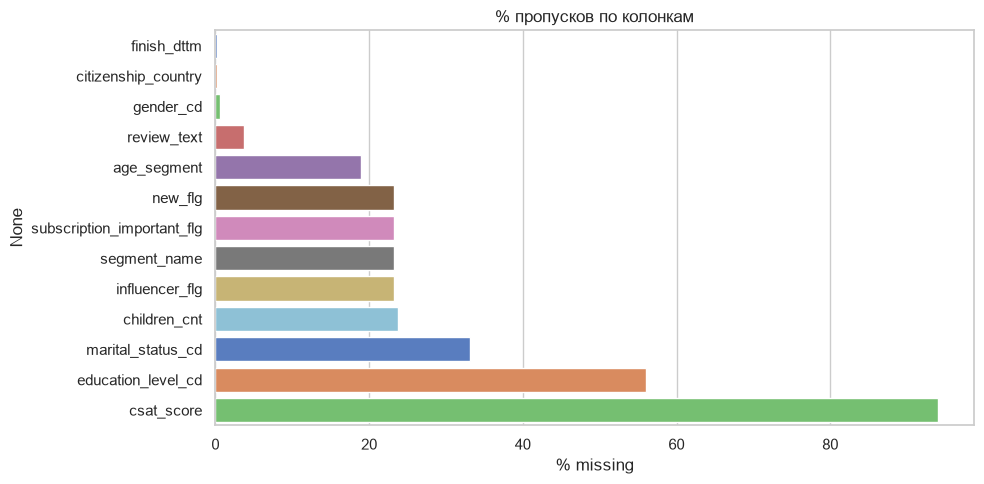

In [28]:
pct_missing = df.isna().mean().sort_values() * 100
pct_missing = pct_missing[pct_missing > 0]
sns.barplot(x=pct_missing.values, y=pct_missing.index, hue=pct_missing.index, palette='muted', legend=False)
plt.title('% пропусков по колонкам')
plt.xlabel('% missing')
plt.tight_layout()

## Univariate анализ категориальных признаков

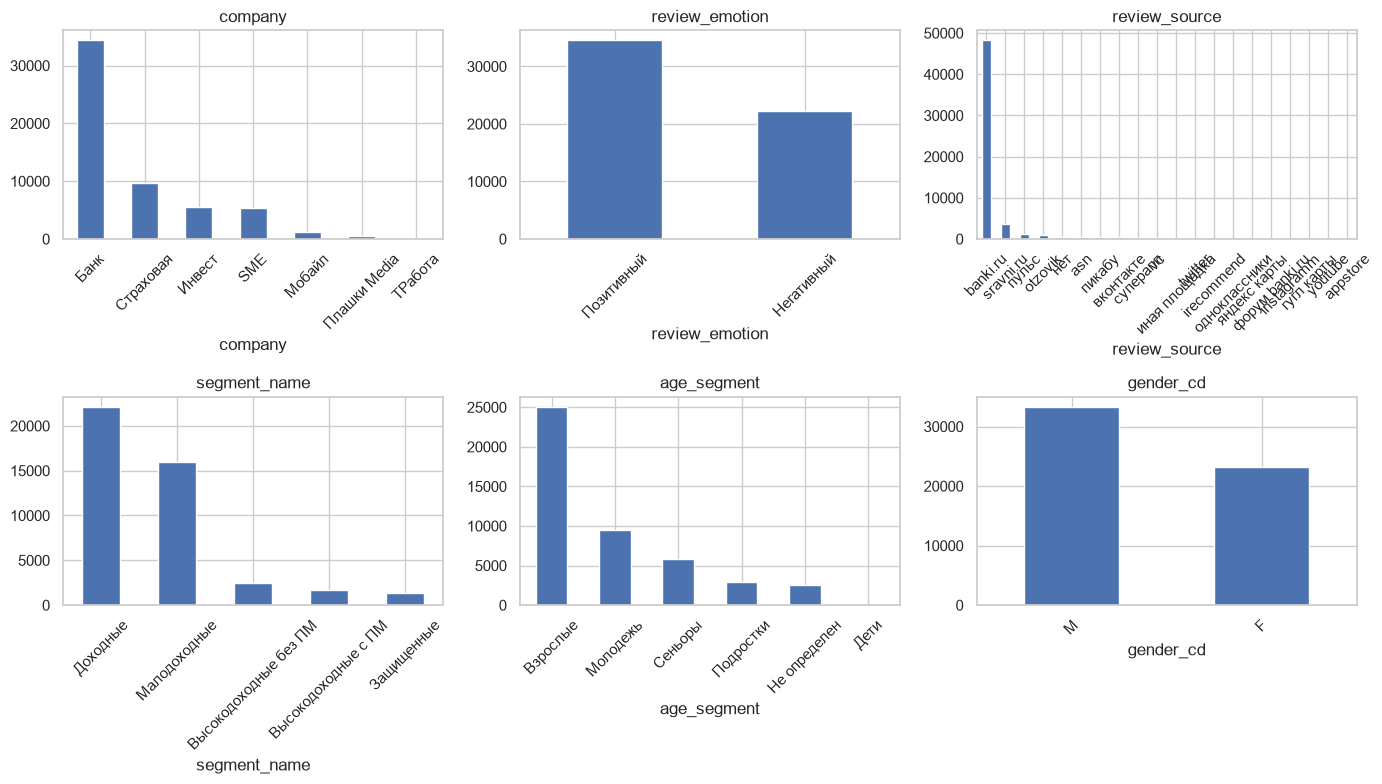

In [29]:
cat_cols_small = ['company', 'review_emotion', 'review_source', 'segment_name', 'age_segment', 'gender_cd']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for col, ax in zip(cat_cols_small, axes.ravel()):
    df[col].value_counts().plot(kind='bar', ax=ax, title=col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

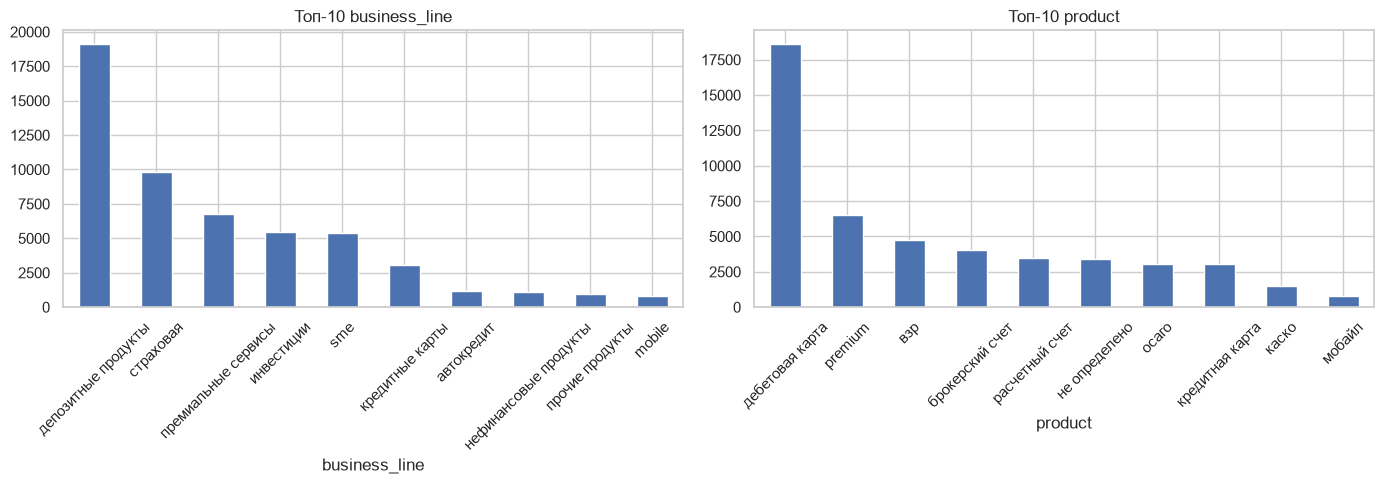

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['business_line'].value_counts().head(10).plot(kind='bar', ax=axes[0], title='Топ-10 business_line')
axes[0].tick_params(axis='x', rotation=45)
df['product'].value_counts().head(10).plot(kind='bar', ax=axes[1], title='Топ-10 product')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()

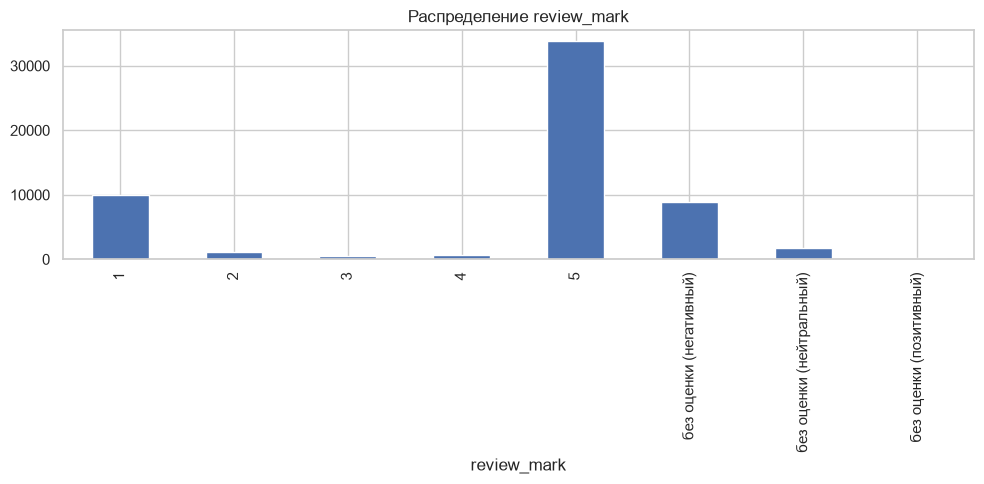

In [31]:
df['review_mark'].value_counts().sort_index().plot(kind='bar', title='Распределение review_mark')
plt.tight_layout()

## Темпоральный анализ

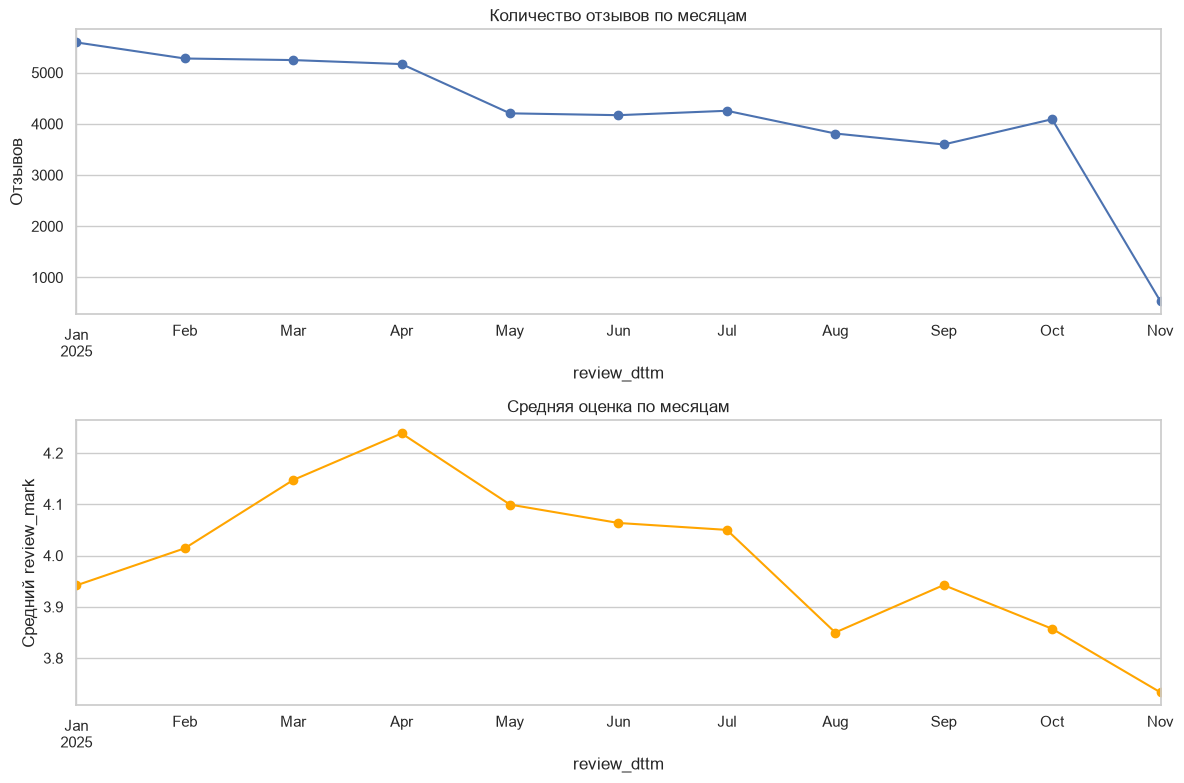

In [32]:
df['review_dttm'] = pd.to_datetime(df['review_dttm'])
numeric_marks = df[df['review_mark'].str.match(r'^\d+$')].copy()
numeric_marks['review_mark_num'] = numeric_marks['review_mark'].astype(int)

monthly = numeric_marks.set_index('review_dttm').resample('ME').agg(
    reviews=('id_client', 'size'),
    avg_mark=('review_mark_num', 'mean')
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
monthly['reviews'].plot(ax=axes[0], title='Количество отзывов по месяцам', marker='o')
axes[0].set_ylabel('Отзывов')
monthly['avg_mark'].plot(ax=axes[1], title='Средняя оценка по месяцам', color='orange', marker='o')
axes[1].set_ylabel('Средний review_mark')
plt.tight_layout()

## Bivariate анализ

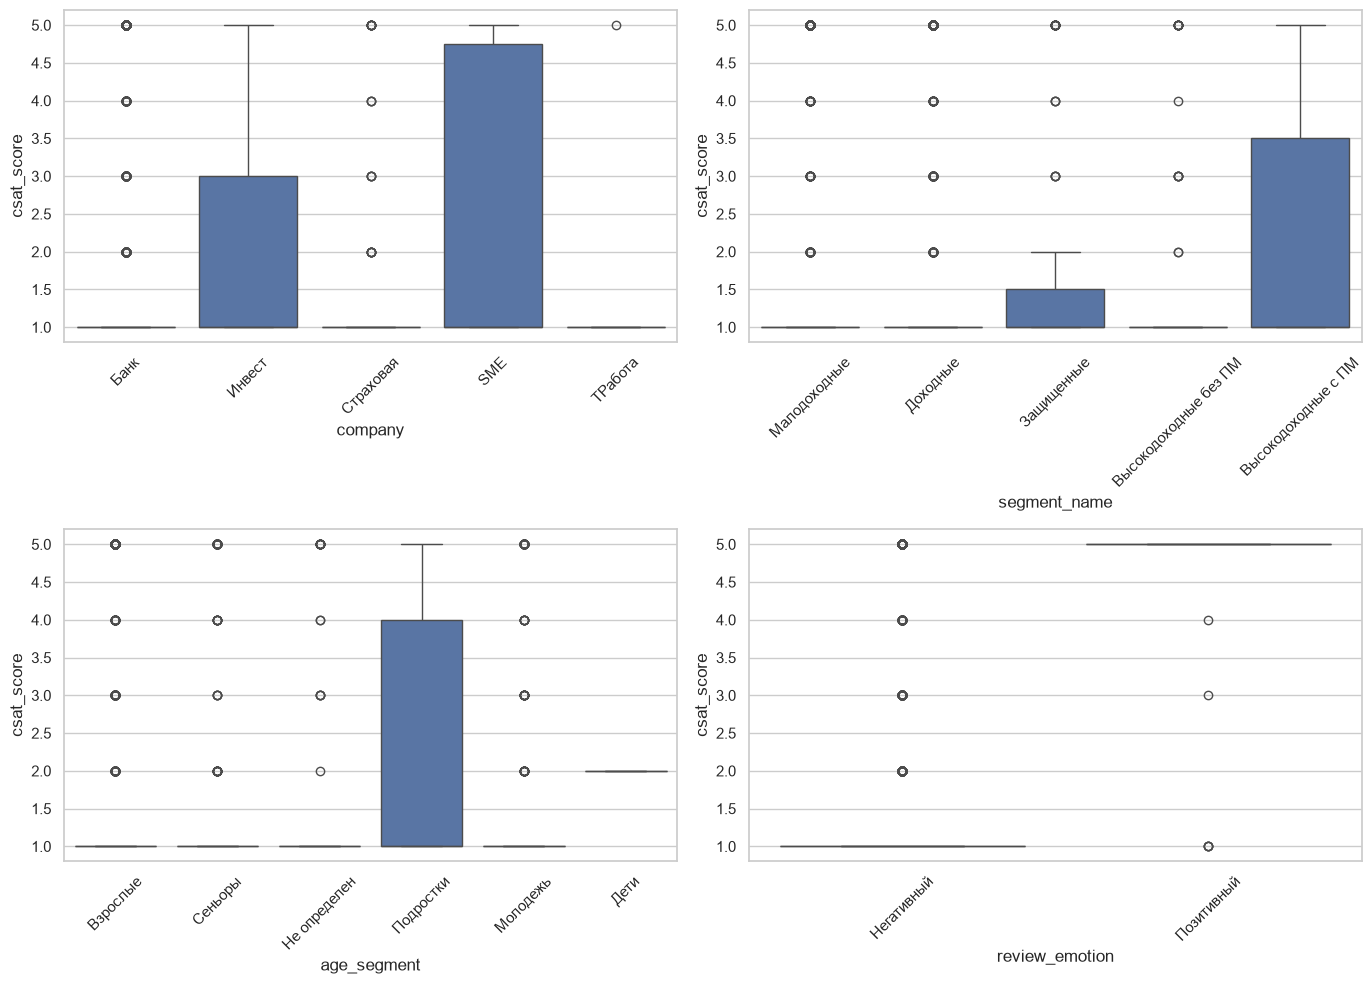

In [33]:
# csat_score vs признаки
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
csat_data = df.dropna(subset=['csat_score']).copy()
sns.boxplot(data=csat_data, x='company', y='csat_score', ax=axes[0, 0])
sns.boxplot(data=csat_data, x='segment_name', y='csat_score', ax=axes[0, 1])
sns.boxplot(data=csat_data, x='age_segment', y='csat_score', ax=axes[1, 0])
sns.boxplot(data=csat_data, x='review_emotion', y='csat_score', ax=axes[1, 1])
for ax in axes.ravel():
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

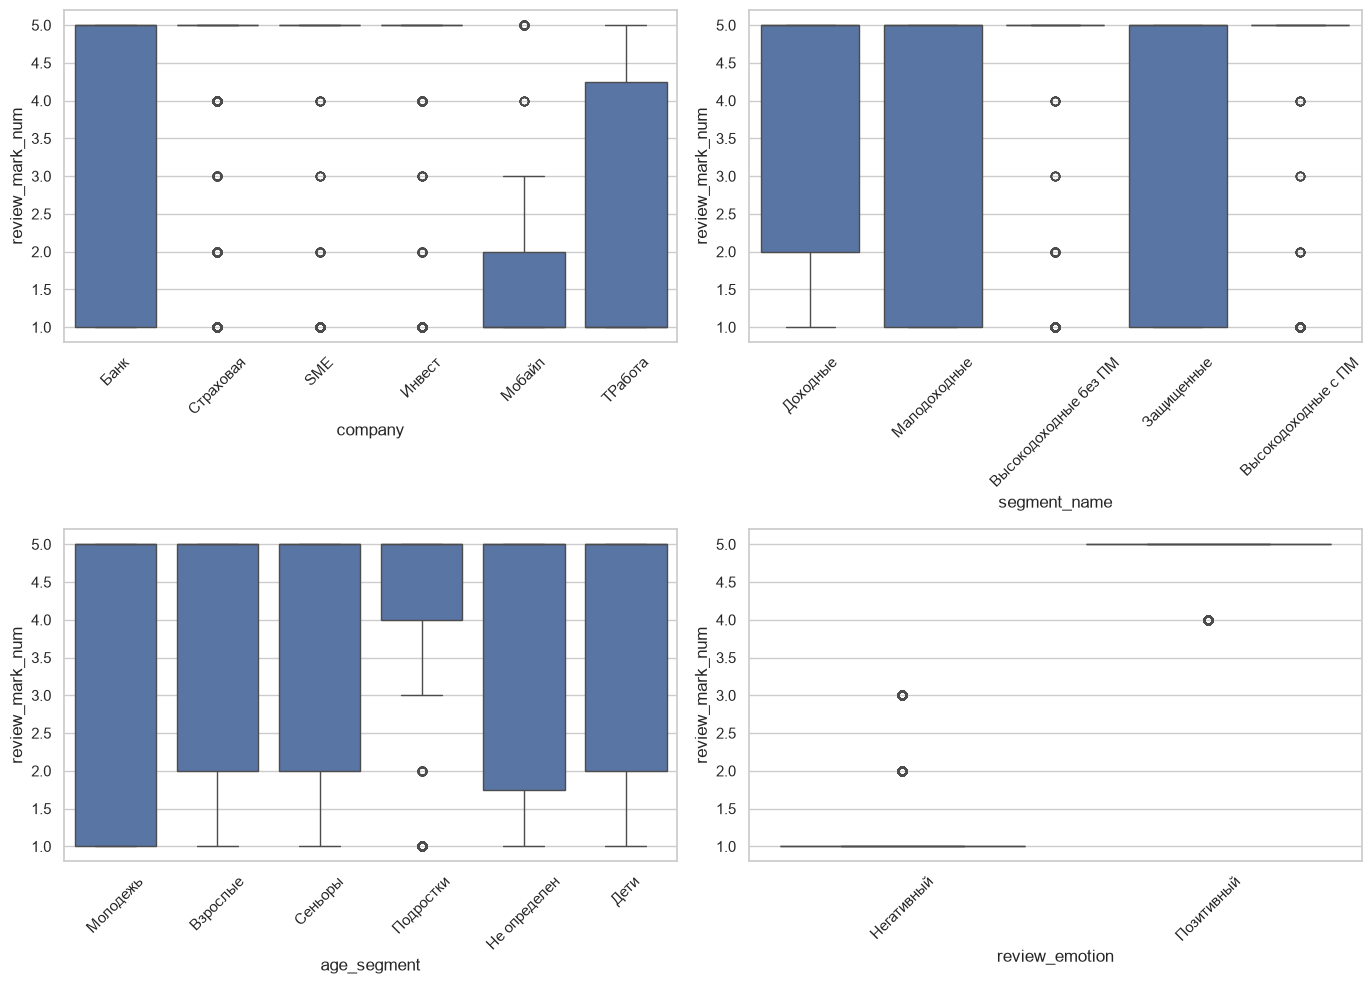

In [34]:
# review_mark vs признаки (только числовые оценки)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
mark_data = numeric_marks.copy()
sns.boxplot(data=mark_data, x='company', y='review_mark_num', ax=axes[0, 0])
sns.boxplot(data=mark_data, x='segment_name', y='review_mark_num', ax=axes[0, 1])
sns.boxplot(data=mark_data, x='age_segment', y='review_mark_num', ax=axes[1, 0])
sns.boxplot(data=mark_data, x='review_emotion', y='review_mark_num', ax=axes[1, 1])
for ax in axes.ravel():
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

## Анализ тональности

In [35]:
print("=== review_emotion vs review_mark (нормировано по колонкам) ===")
print(pd.crosstab(df['review_emotion'], df['review_mark'], normalize='columns').round(3))
print()
print("=== review_emotion vs company (нормировано по колонкам) ===")
print(pd.crosstab(df['review_emotion'], df['company'], normalize='columns').round(3))

=== review_emotion vs review_mark (нормировано по колонкам) ===
review_mark       1    2    3    4    5  без оценки (негативный)  \
review_emotion                                                     
Негативный      1.0  1.0  1.0  0.0  0.0                      1.0   
Позитивный      0.0  0.0  0.0  1.0  1.0                      0.0   

review_mark     без оценки (нейтральный)  без оценки (позитивный)  
review_emotion                                                     
Негативный                           1.0                      0.0  
Позитивный                           0.0                      1.0  

=== review_emotion vs company (нормировано по колонкам) ===
company           SME   Банк  Инвест  Мобайл  Плашки Media  Страховая  ТРабота
review_emotion                                                                
Негативный      0.124  0.484   0.365    0.93           1.0      0.125    0.913
Позитивный      0.876  0.516   0.635    0.07           0.0      0.875    0.087


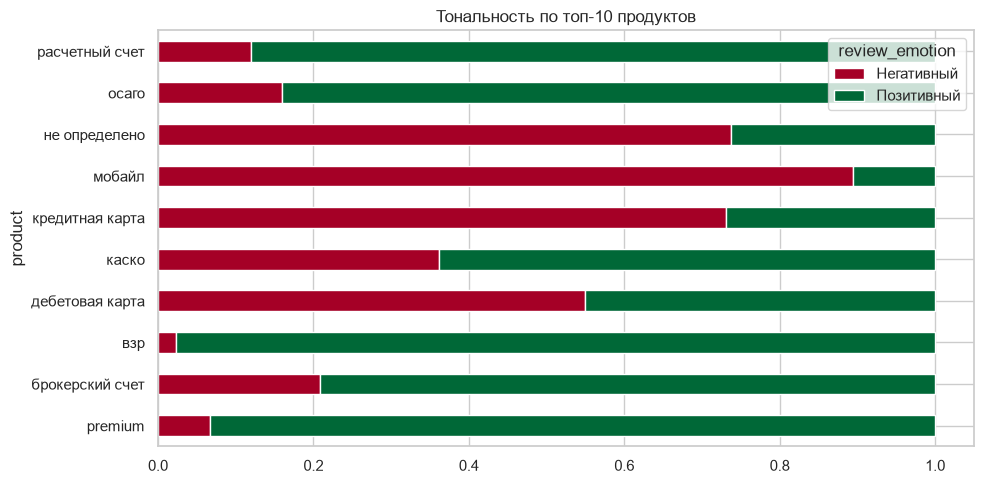

In [36]:
top_products = df['product'].value_counts().head(10).index
prod_sent = df[df['product'].isin(top_products)].groupby('product')['review_emotion'].value_counts(normalize=True).unstack()
prod_sent.plot(kind='barh', stacked=True, title='Тональность по топ-10 продуктов', colormap='RdYlGn')
plt.tight_layout()

## Анализ текстов отзывов

In [37]:
df['text_len'] = df['review_text'].str.len()
df['text_len'].describe()

count    54723.000000
mean       622.274199
std        465.405328
min          1.000000
25%        331.000000
50%        455.000000
75%        762.000000
max       4000.000000
Name: text_len, dtype: float64

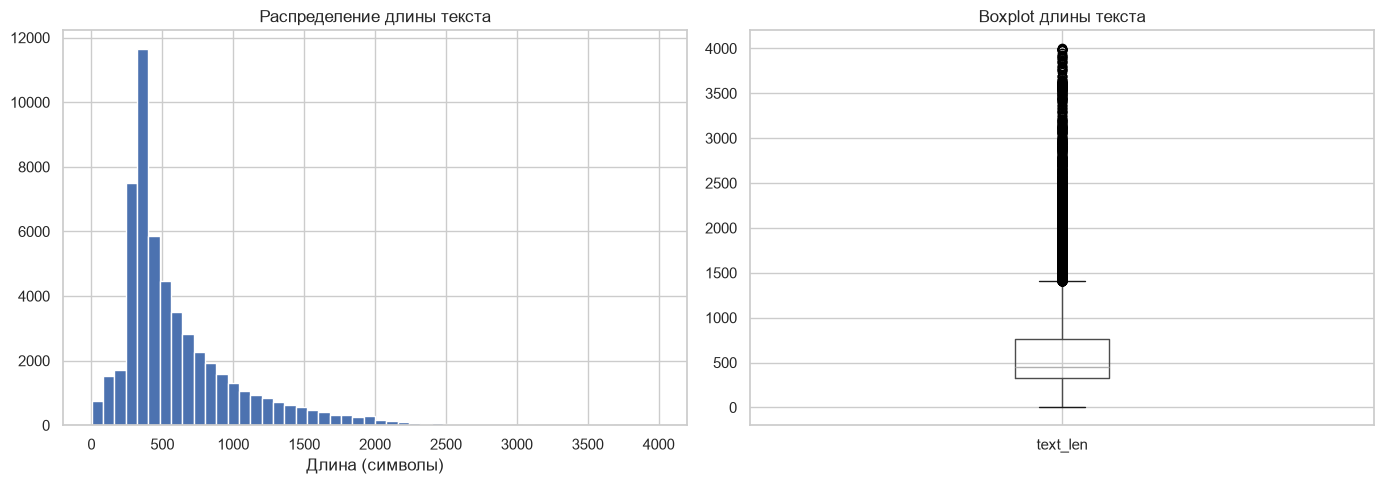

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['text_len'].hist(bins=50, ax=axes[0])
axes[0].set_title('Распределение длины текста')
axes[0].set_xlabel('Длина (символы)')
df.boxplot(column='text_len', ax=axes[1])
axes[1].set_title('Boxplot длины текста')
plt.tight_layout()

## Корреляция числовых признаков

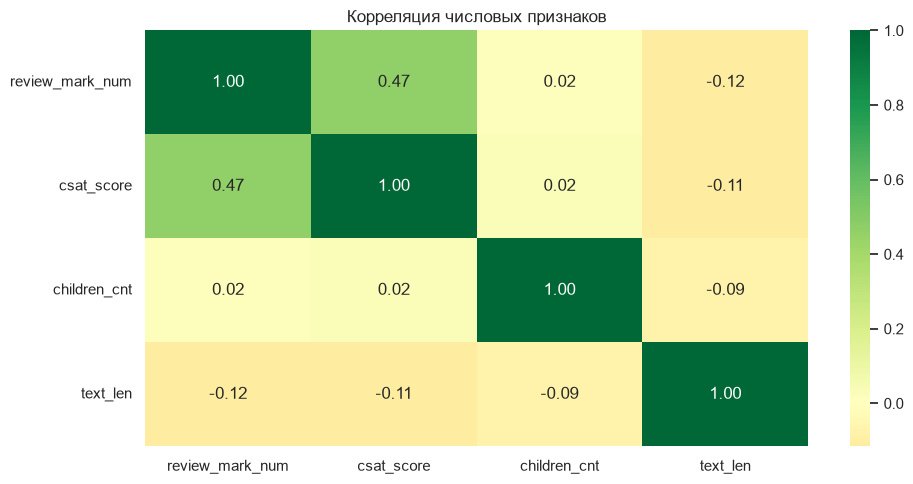

In [39]:
df['review_mark_num'] = pd.to_numeric(df['review_mark'], errors='coerce')
num_df = df[['review_mark_num', 'csat_score', 'children_cnt', 'text_len']].dropna()
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Корреляция числовых признаков')
plt.tight_layout()

## Выводы по EDA

1. **Пропуски**: сильная разреженность — `csat_score` заполнен лишь у 6% записей (3407 из 56820). `education_level_cd` (~56%), `marital_status_cd` (~33%), `segment_name`/`new_flg`/`subscription_important_flg`/`influencer_flg` (~23%) также имеют значительные пропуски.

2. **Целевая переменная**: сильный дисбаланс — 80% значений csat_score = 1.0. Это важно учесть при моделировании (стратификация, метрики).

3. **review_mark**: имеет нечисловые значения ('без оценки (негативный)', 'без оценки (нейтральный)'). Числовые оценки смещены к 1 и 5 (U-образное распределение).

4. **Темпоральность**: отзывы распределены равномерно в течение 2025 года.

5. **Сегменты**: основная масса клиентов — Банк (депозитные продукты, дебетовые/кредитные карты). Сегменты 'Доходные' и 'Взрослые' доминируют.

6. **csat_score vs review_mark**: есть корреляция — низкий review_mark чаще соответствует csat_score = 1, высокий — csat_score = 5. Но есть и расхождения (detractors, которые ставят 5 и наоборот).

7. **Дубликаты**: отсутствуют.